In [3]:
from pathlib import Path 
import pandas as pd 

data_dir = Path("data")
files = list(data_dir.glob("*.csv"))

from collections import Counter
Counter(tuple(pd.read_csv(file,nrows=0).columns) for file in files)

Counter({('Voltage_measured',
          'Current_measured',
          'Temperature_measured',
          'Current_charge',
          'Voltage_charge',
          'Time'): 2815,
         ('Voltage_measured',
          'Current_measured',
          'Temperature_measured',
          'Current_load',
          'Voltage_load',
          'Time'): 2794,
         ('Sense_current',
          'Battery_current',
          'Current_ratio',
          'Battery_impedance',
          'Rectified_Impedance'): 1956})

In [5]:
charge_files = []
discharge_files = []
impedance_files = []

for file in files: 
    cols = tuple(pd.read_csv(file, nrows=0).columns)

    if "Current_charge" in cols: 
        charge_files.append(file)

    elif "Current_load" in cols:
        discharge_files.append(file)

    elif "Battery_impedance" in cols:
        impedance_files.append(file)

charge_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in charge_files],
    ignore_index=True
)

discharge_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in discharge_files],
    ignore_index=True
)

impedance_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in impedance_files],
    ignore_index=True
)

In [6]:
print(len(charge_files))
print(len(discharge_files))
print(len(impedance_files))

2815
2794
1956


In [36]:
metadata = pd.read_csv("metadata.csv")
metadata.shape

(7565, 10)

In [56]:
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [58]:
metadata[metadata['type'] == 'discharge'].value_counts('battery_id')

battery_id
B0033    197
B0036    197
B0034    197
B0005    168
B0007    168
B0006    168
B0018    132
B0044    112
B0043    112
B0042    112
B0054    103
B0055    102
B0056    102
B0046     72
B0045     72
B0048     72
B0047     72
B0041     67
B0053     56
B0040     47
B0039     47
B0038     47
B0029     40
B0031     40
B0030     40
B0032     40
B0028     28
B0027     28
B0026     28
B0025     28
B0049     25
B0050     25
B0051     25
B0052     25
Name: count, dtype: int64

In [60]:
metadata[metadata['type'] == 'discharge'].head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


In [ ]:
metadata.groupby(metadata['type'] == 'discharge')['Capacity']

In [ ]:
new_df = metadata.loc[(metadata['type'] == 'discharge') & (metadata['battery_id'] == 'B0047'), ['Capacity']].copy()
new_df['cycle'] = range(1,len(new_df)+1)
new_df['Capacity'] = new_df['Capacity'].astype(float)
new_df[new_df['Capacity'] == 0].value_counts()

Capacity  cycle
0.0       20       1
          54       1
          66       1
Name: count, dtype: int64

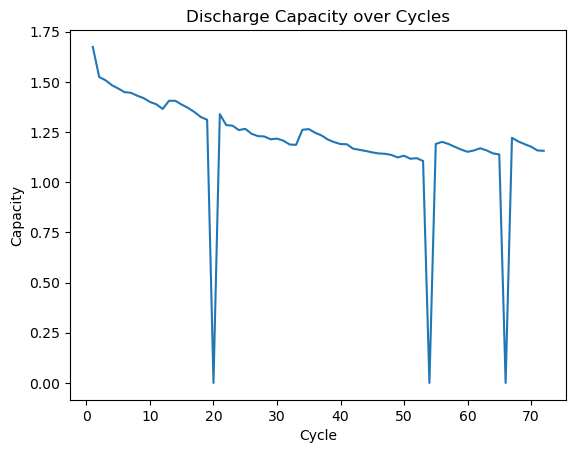

In [77]:
import matplotlib.pyplot as plt
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('Discharge Capacity over Cycles')
plt.plot(new_df['cycle'], new_df['Capacity'])
plt.show()